Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:6 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [4,387 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,944 kB]
Get:13 http://security.ubuntu.co

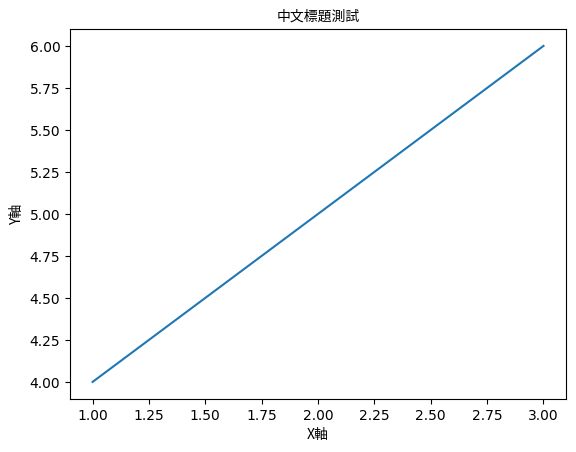

In [50]:
!apt-get -y update && apt-get -y install fonts-noto-cjk

# 中文字型設定
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
chinese_font = fm.FontProperties(fname=font_path)

# 畫圖測試
plt.figure()
plt.title("中文標題測試", fontproperties=chinese_font)
plt.xlabel("X軸", fontproperties=chinese_font)
plt.ylabel("Y軸", fontproperties=chinese_font)
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [ ]:
# 整合比較：7天與30天輸入, 各使用 LSTM 1層與3層，僅保留 Accuracy、Recall、F1
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 讀取資料
file_paths = [
    "/content/全家2024年12月班表.csv",
    "/content/全家2025年1月班表.csv",
    "/content/全家2025年3月班表.csv",
    "/content/全家2025年4月班表.csv"
]
df_list = [pd.read_csv(p) for p in file_paths]
df_raw = pd.concat(df_list, ignore_index=True)
df_raw["日期"] = pd.to_datetime(dict(year=df_raw["year"], month=df_raw["month"], day=df_raw["date"]))
df_raw.drop(columns=["year", "month", "date", "day of week"], errors="ignore", inplace=True)

# 整理班別
long_df = df_raw.melt(id_vars=["日期"], value_vars=[c for c in df_raw.columns if "_s" in c],
                      var_name="員工", value_name="起始時間")
long_df["員工"] = long_df["員工"].str.replace("_s", "").str.replace("member_", "").str.upper()
long_df["起始時間"] = pd.to_numeric(long_df["起始時間"], errors="coerce")

def classify_shift(x):
    if pd.isna(x): return 0
    elif 6 <= x < 11: return 1
    elif 11 <= x < 15: return 2
    elif 15 <= x <= 24: return 3
    else: return 0

long_df["班別"] = long_df["起始時間"].apply(classify_shift)
df_grouped = long_df.groupby(["日期", "員工"])["班別"].min().reset_index()
df_pivot = df_grouped.pivot(index="日期", columns="員工", values="班別").sort_index()
df_weekday = pd.DataFrame(index=df_pivot.index)
df_weekday["星期幾"] = df_weekday.index.weekday
employee_ids = df_pivot.columns.tolist()

# 建立序列資料
def create_dataset(df_pivot, df_weekday, employee_ids, window_size=7):
    X, y = [], []
    for emp_id in employee_ids:
        series = df_pivot[emp_id].values
        weekday_series = df_weekday["星期幾"].values
        for i in range(len(series) - window_size):
            X.append([[series[i+j], weekday_series[i+j]] for j in range(window_size)])
            y.append(series[i + window_size])
    return np.array(X), np.array(y)

# 定義 LSTM 模型
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# 執行訓練與測試
def run_experiment(window_size=7, num_layers=1, epochs=50):
    X, y = create_dataset(df_pivot, df_weekday, employee_ids, window_size)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X.reshape(-1, 2)).reshape(X.shape)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    model = LSTMModel(input_size=2, hidden_size=64, num_layers=num_layers, num_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    for epoch in range(epochs):
        model.train()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        predicted = torch.argmax(y_pred, dim=1).numpy()

    accuracy = accuracy_score(y_test, predicted)
    recall = recall_score(y_test, predicted, average='macro')
    f1 = f1_score(y_test, predicted, average='macro')
    return accuracy, recall, f1

# 執行四組實驗：7天/30天 × 1層/3層
results = []
for win in [7, 30]:
    for layer in [1, 3]:
        acc, rec, f1 = run_experiment(window_size=win, num_layers=layer)
        results.append((f"{win}天-{layer}層", acc, rec, f1))

# 顯示比較表格
comparison_df = pd.DataFrame(results, columns=["模型設計", "準確率 Accuracy", "召回率 Recall", "F1 分數"])
print(comparison_df)

# 正確的圖表呈現方式：每個指標一張圖（群組條形圖更易比較）
metrics = ["準確率 Accuracy", "召回率 Recall", "F1 分數"]
colors = ["skyblue", "orange", "lightgreen"]

plt.figure(figsize=(14, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    plt.bar(comparison_df["模型設計"], comparison_df[metric], color=colors[i])
    plt.ylim(0, 1.0)
    plt.title(metric)
    plt.xlabel("模型設計")
    plt.ylabel("分數")
    plt.xticks(rotation=15)

plt.suptitle("7天與30天輸入 × LSTM 層數比較指標", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

